# M2.Ex1: Advertising Revenue

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M2/exercises/ex1_multi-reg.ipynb)

In [1]:
import pandas as pd
import sklearn
import seaborn as sns

from sklearn.impute import SimpleImputer                                                                                
from sklearn.preprocessing import StandardScaler                                                                        
from sklearn.linear_model import LinearRegression    

from sklearn.model_selection import train_test_split


## Advertising Dataset

The Advertising Dataset is a fundamental resource in statistical learning and regression analysis. It is primarily known for its use in the first chapter of the seminal textbook "An Introduction to Statistical Learning" (ISLR) by Gareth James, Daniela Witten, Trevor Hastie, and Robert Tibshirani.

The dataset is used to illustrate the relationship between advertising budgets across different media and the resulting product sales.

- Features: `3` numerical
- Target: `sales` of the product (in thousands of units).
- Size: `200` samples.
- Source: [Advertising Dataset](https://www.statlearning.com/s/Advertising.csv)

### Step 1. Load the data

In [2]:
df=pd.read_csv("../../datasets/advertising.csv")
df=df.drop('Unnamed: 0',axis=1)
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
X = df[['TV','radio','newspaper']]
y = df['sales']

### Step 2.b print the type of each

In [4]:
print(f'X: {type(X)}\ndtypes:\n{X.dtypes}')
print('--------------')
print(f'y: {type(y)}\ndtype:\n {y.dtype}')

X: <class 'pandas.DataFrame'>
dtypes:
TV           float64
radio        float64
newspaper    float64
dtype: object
--------------
y: <class 'pandas.Series'>
dtype:
 float64


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

**Answer**: Target is numerical so it is a regression task

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [5]:
print(len(X))
print(len(y))

200
200


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [6]:
print('All data')
df.describe()


All data


,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [7]:
print('Features only')
X.describe()

Features only


,TV,radio,newspaper
count,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000
std,85.854236,14.846809,21.778621
min,0.700000,0.000000,0.300000
25%,74.375000,9.975000,12.750000
50%,149.750000,22.900000,25.750000
75%,218.825000,36.525000,45.100000
max,296.400000,49.600000,114.000000


### Step 5. How much difference do you see in the scale of each feature? (calculate the featre-wise range differences)

In [8]:
Tv_range = X['TV'].max()-X['TV'].min()
radio_range = X['radio'].max()-X['radio'].min()
np_range = X['newspaper'].max()-X['newspaper'].min()

print(f"TV: {Tv_range:.1f}\nRadio: {radio_range:.1f}\nNewspaper: {np_range:.1f}")


TV: 295.7
Radio: 49.6
Newspaper: 113.7


### Step 6.a Plot each of the features vs the target

Hint use this: `sns.pairplot()`

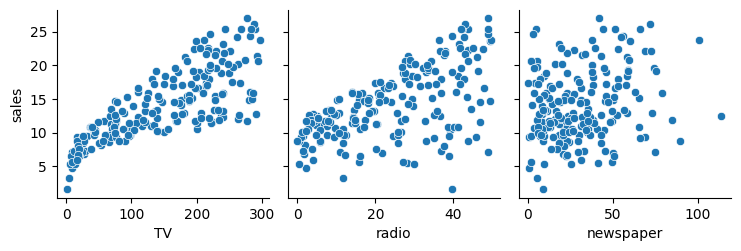

In [9]:
sns.pairplot(df, x_vars=['TV', 'radio', 'newspaper'], y_vars=['sales'])                                                 


### Step 6.b What is the relationship between the feature and the target? (increasing or decreasing or none)

1. `x=TV` and `y=Sales`
2. `x=Radio` and `y=Sales`
3. `x=Newspaper` and `y=Sales`

**Answer**:

from the interpretation from the viz 

- `sales` and `TV` has possitive correlation (increasing)

- `sales` and `radio` has possitive correlation but is lower than `sales` and `TV`

- `sales` ans `newspaper` seems to have  weak / no clear relationship

### Step 7. Define the pipeline with pre-processing steps

Make a Pipeline of three sequential steps:

1. transformer: `SimpleImputer` (to fill in missing values)
2. transformer: `StandardScaler` (to scale numerical features)
3. predictor: `LinearRegression` (to model the relationship)

In [10]:
from sklearn.pipeline import Pipeline

preprocessing = Pipeline(steps=[('imputer',SimpleImputer(strategy='mean')),
                                ('scaler',StandardScaler())])
predictor = LinearRegression()

In [11]:
pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessing),
        ("regressor", predictor),
    ]
)

### Step 8. Split the dataset into train and test sets

In [12]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### Step 9.a Fit the pipeline on the training set

In [13]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str

### Step 9.b Identify the learned coefficients (for each feature) and the bias term

In [14]:
print(f"Coefficients: {pipe['regressor'].coef_}")                                                                       
print(f"Intercept (bias): {pipe['regressor'].intercept_:.2f}")  
model= pipe['regressor']      

Coefficients: [3.76419618 2.79230665 0.05597551]
Intercept (bias): 14.10


### Step 9.c how much spending on TV `$1,000` more, factor into Sales?

In [15]:
print(f'spending 1000$ more on tv will add {(1000*pipe['regressor'].coef_[0]):.2f} dollars')

spending 1000$ more on tv will add 3764.20 dollars


### Step 9.d if we take `$5,000` away from Newspaper and put it in Radio how much difference does that make into Sales?

In [16]:
df.columns

Index(['TV', 'radio', 'newspaper', 'sales'], dtype='str')

In [17]:
sales_newspaper= -(5 * model.coef_[2]) #minus because we are removing it 
sales_radio= (5 * model.coef_[1])
diff=sales_radio + sales_newspaper
print(f'the difference would be {diff:.2f}k ')

the difference would be 13.68k 


### Step 9.e if we spend nothing at all on advertising, how much do we estimate our Sales to be?

In [18]:
#here we use intercept because it is the value when input is 0
print(f"Estimated sales with no advertising: {pipe['regressor'].intercept_:.2f}k $")                                



Estimated sales with no advertising: 14.10k $


### Step 10. Evaluate the pipeline on the test set

In [19]:
score = pipe.score(X_test, y_test)
print(score)

0.8994380241009119


### Step 11. Define a `LinearRegression` model without the pre-processing steps, and compare it's score with the pipeline. Which one is better?

In [21]:
model_2= LinearRegression()
model_2.fit(X_train,y_train)
model_2.score(X_test,y_test)


0.899438024100912

Answer: 

the core between the one with pipeline and preprocessing and the regular one seems close and that might be because of multiple reasons one of them might be the size of data itself